<a href="https://colab.research.google.com/github/SimonT0910/Management-information-systems/blob/main/Management_information_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import plotly.express as px
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://github.com"
df = pd.read_excel(url)

### Classification Model

prepare data

In [12]:
scaler = StandardScaler()

print("Unique values in IMPORTANCIA:")
print(df['IMPORTANCIA'].value_counts())
print("\n" + "="*50 + "\n")

columnas = ['ORDEN DE LA ENTIDAD', 'SECTOR', 'REGIÓN',
            'DEPARTAMENTO', 'CLASIFICACIÓN TAXONOMÍA',
            'TIPO DE INCIDENTE', 'DIA', 'MES', 'AÑO'
            ]

df_ml = df[columnas + ['IMPORTANCIA']].copy()
df_ml = df_ml.dropna(subset=['IMPORTANCIA'])

print(f"Dataset ready: {df_ml.shape[0]} rows, {df_ml.shape[1]} columns")

Unique values in IMPORTANCIA:
IMPORTANCIA
Menor        2432
Solicitud    1494
Grave        1141
Muy Grave      49
Name: count, dtype: int64


Dataset ready: 5116 rows, 10 columns


Encoding and Splitting Data

In [13]:
label_encoders = {}
for col in df_ml.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

X = df_ml.drop('IMPORTANCIA', axis=1)
y = df_ml['IMPORTANCIA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categoria_nombres = list(label_encoders['IMPORTANCIA'].classes_)
print(f"Training: {X_train.shape[0]} rows")
print(f"Testing: {X_test.shape[0]} rows")
print(f"Categories to Predict: {y.nunique()}")
print(f"Category Names: {categoria_nombres}")

Training: 4092 rows
Testing: 1024 rows
Categories to Predict: 4
Category Names: ['Grave', 'Menor', 'Muy Grave', 'Solicitud']


Train models and compare

In [16]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
precision_rf = accuracy_score(y_test, y_pred_rf)

xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.1,
                              random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
precision_xgb = accuracy_score(y_test, y_pred_xgb)

print("Model Results:")
print(f"Random Forest: {precision_rf*100:.2f}%")
print(f"XGBoost: {precision_xgb*100:.2f}%")

if precision_xgb >= precision_rf:
    mejor_modelo = xgb_model
    mejor_pred = y_pred_xgb
    print(f"\nThe best model is: XGBoost with {precision_xgb*100:.2f}%")
else:
    mejor_modelo = rf
    mejor_pred = y_pred_rf
    print(f"\nThe best model is: Random Forest with {precision_rf*100:.2f}%")

Model Results:
Random Forest: 89.84%
XGBoost: 91.02%

The best model is: XGBoost with 91.02%


Confusion matrix and key characteristics

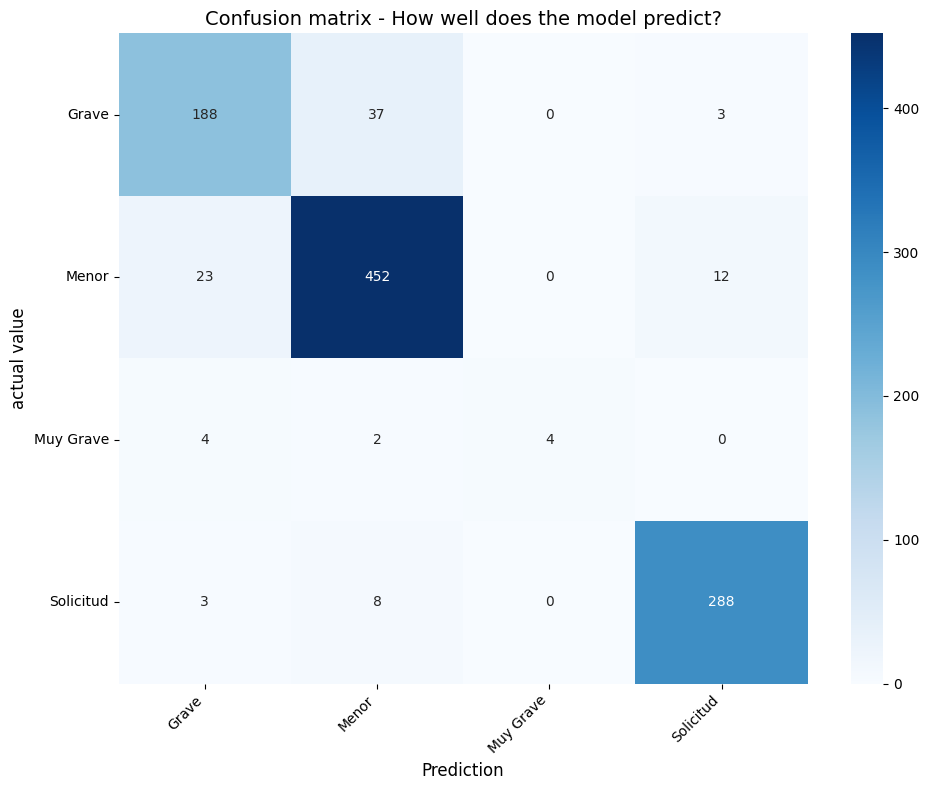


Classification report:
              precision    recall  f1-score   support

       Grave       0.86      0.82      0.84       228
       Menor       0.91      0.93      0.92       487
   Muy Grave       1.00      0.40      0.57        10
   Solicitud       0.95      0.96      0.96       299

    accuracy                           0.91      1024
   macro avg       0.93      0.78      0.82      1024
weighted avg       0.91      0.91      0.91      1024


The 5 Most Important Features:
1. CLASIFICACIÓN TAXONOMÍA: 0.6988
2. TIPO DE INCIDENTE: 0.1282
3. AÑO: 0.0716
4. MES: 0.0229
5. DIA: 0.0165


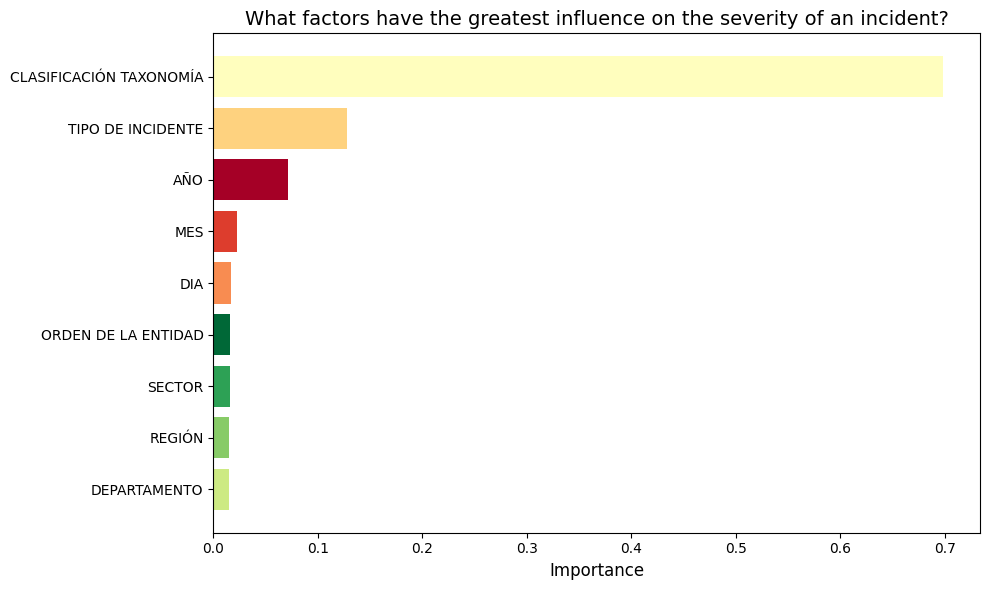


Model ready to predict new incidents


In [19]:
cm = confusion_matrix(y_test, mejor_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categoria_nombres,
            yticklabels=categoria_nombres)
plt.title("Confusion matrix - How well does the model predict?", fontsize=14)
plt.xlabel('Prediction', fontsize=12)
plt.ylabel('actual value', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test, mejor_pred, target_names=categoria_nombres))

importancia = mejor_modelo.feature_importances_
caracteristicas = X.columns
indices = np.argsort(importancia)[::-1]

print("\nThe 5 Most Important Features:")
print("="*40)
for i in range(min(5, len(caracteristicas))):
    print(f"{i+1}. {caracteristicas[indices[i]]}: {importancia[indices[i]]:.4f}")

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(importancia)))
plt.barh(range(len(importancia)), importancia[indices], color=colors[indices])
plt.yticks(range(len(importancia)), [caracteristicas[i] for i in indices])
plt.xlabel('Importance', fontsize=12)
plt.title('What factors have the greatest influence on the severity of an incident?', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nModel ready to predict new incidents")

New incidents to test the model's performance

In [21]:
columnas_clustering = ['ORDEN DE LA ENTIDAD', 'SECTOR', 'REGIÓN',
                       'DEPARTAMENTO', 'CLASIFICACIÓN TAXONOMÍA',
                       'TIPO DE INCIDENTE', 'DIA', 'MES', 'AÑO']

df_cluster_temp = df[columnas_clustering].copy()
df_cluster_temp = df_cluster_temp.dropna()

label_cluster_temp = {}
for col in df_cluster_temp.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_cluster_temp[col] = le.fit_transform(df_cluster_temp[col].astype(str))
    label_cluster_temp[col] = le

datos_escalados_temp = scaler.fit_transform(df_cluster_temp)
kmeans_global = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_global.fit(datos_escalados_temp)

nuevo_incidente = {
    'ORDEN DE LA ENTIDAD': 'Privada',
    'SECTOR': 'privado',
    'REGIÓN': 'Bogotá D.C.',
    'DEPARTAMENTO': 'Bogotá D.C.',
    'CLASIFICACIÓN TAXONOMÍA': 'Fraude',
    'TIPO DE INCIDENTE': 'phishing',
    'DIA': 4,
    'MES': 'May',
    'AÑO': 2026
}

nuevo_df = pd.DataFrame([nuevo_incidente])

for col in nuevo_df.columns:
    if col in label_encoders:
        if nuevo_df[col].iloc[0] in label_encoders[col].classes_:
            nuevo_df[col] = label_encoders[col].transform(nuevo_df[col])
        else:
            print(f"Warning: {col}={nuevo_df[col].iloc[0]} Not found; using default value")
            nuevo_df[col] = 0
for col in X.columns:
    if col not in nuevo_df.columns:
        nuevo_df[col] = 0
nuevo_df = nuevo_df[X.columns]

prediccion_num = mejor_modelo.predict(nuevo_df)[0]
prediccion = categoria_nombres[prediccion_num]

print("Prediction of a New Incident")

print("Incident Details:")
for key, value in nuevo_incidente.items():
    print(f"  {key}: {value}")
print(f"\nThe incident is: {prediccion}")

if prediccion == 'Muy Grave':
    print("ATTENTION! Extremely serious incident—top priority.")
elif prediccion == 'Grave':
    print("Serious incident; requires immediate attention.")
elif prediccion == 'Menor':
    print("It's a minor issue; it can wait.")
else:
    print("Just a request for information; no real danger.")

nuevo_df_cluster = pd.DataFrame([nuevo_incidente])
for col in nuevo_df_cluster.columns:
    if col in label_cluster_temp:
        if nuevo_df_cluster[col].iloc[0] in label_cluster_temp[col].classes_:
            nuevo_df_cluster[col] = label_cluster_temp[col].transform(nuevo_df_cluster[col])
        else:
            nuevo_df_cluster[col] = 0

for col in df_cluster_temp.columns:
    if col not in nuevo_df_cluster.columns:
        nuevo_df_cluster[col] = 0
nuevo_df_cluster = nuevo_df_cluster[df_cluster_temp.columns]

nuevo_escalado = scaler.transform(nuevo_df_cluster)
cluster_asignado = kmeans_global.predict(nuevo_escalado)[0]
print(f"The new case is part of the cluster: {cluster_asignado}")

Prediction of a New Incident
Incident Details:
  ORDEN DE LA ENTIDAD: Privada
  SECTOR: privado
  REGIÓN: Bogotá D.C.
  DEPARTAMENTO: Bogotá D.C.
  CLASIFICACIÓN TAXONOMÍA: Fraude
  TIPO DE INCIDENTE: phishing
  DIA: 4
  MES: May
  AÑO: 2026

The incident is: Menor
It's a minor issue; it can wait.
The new case is part of the cluster: 0


### Clustering

Preparing Data for Clustering

In [25]:
columnas_clustering = ['ORDEN DE LA ENTIDAD', 'SECTOR', 'REGIÓN',
                       'DEPARTAMENTO', 'CLASIFICACIÓN TAXONOMÍA',
                       'TIPO DE INCIDENTE', 'DIA', 'MES', 'AÑO']

df_cluster = df[columnas_clustering].copy()
df_cluster = df_cluster.dropna()
print(f"Data for clustering: {df_cluster.shape[0]} rows, {df_cluster.shape[1]} columns")

label_cluster = {}
for col in df_cluster.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_cluster[col] = le.fit_transform(df_cluster[col].astype(str))
    label_cluster[col] = le

Data for clustering: 5116 rows, 9 columns


Scaling Data and Finding the Optimal Number of Clusters (Elbow Method)

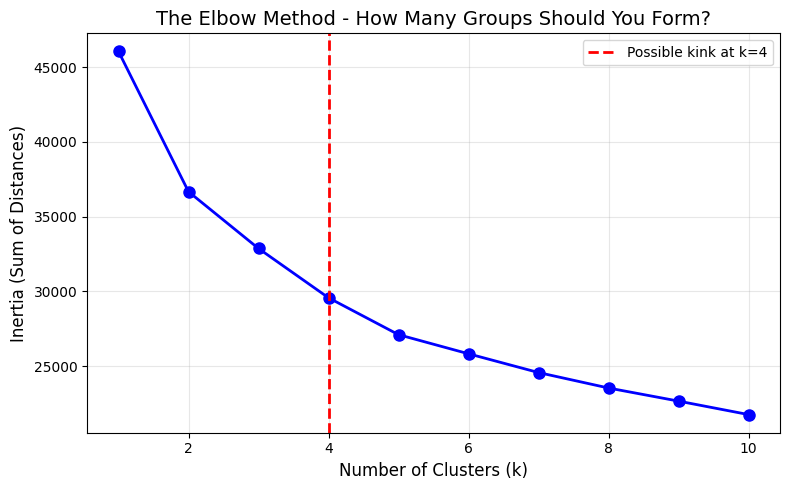

DISTRIBUTION OF INCIDENTS BY CLUSTER
Cluster 0: 2149 incidents
Cluster 1: 978 incidents
Cluster 2: 889 incidents
Cluster 3: 1100 incidents


WHAT KIND OF INCIDENTS OCCUR IN EACH CLUSTER?

CLUSTER 0
Total: 2149 incidents

Distribution by Importance:
IMPORTANCIA
Menor        1098
Solicitud     585
Grave         441
Muy Grave      25
Name: count, dtype: int64



CLUSTER 1
Total: 978 incidents

Distribution by Importance:
IMPORTANCIA
Menor        836
Grave        100
Solicitud     34
Muy Grave      8
Name: count, dtype: int64



CLUSTER 2
Total: 889 incidents

Distribution by Importance:
IMPORTANCIA
Solicitud    402
Grave        340
Menor        145
Muy Grave      2
Name: count, dtype: int64



CLUSTER 3
Total: 1100 incidents

Distribution by Importance:
IMPORTANCIA
Solicitud    473
Menor        353
Grave        260
Muy Grave     14
Name: count, dtype: int64




In [26]:
datos_escalados = scaler.fit_transform(df_cluster)

inercias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(datos_escalados)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inercias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Sum of Distances)', fontsize=12)
plt.title('The Elbow Method - How Many Groups Should You Form?', fontsize=14)
plt.axvline(x=4, color='red', linestyle='--', linewidth=2, label='Possible kink at k=4')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_elegido = 4
kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
df_cluster['CLUSTER'] = kmeans.fit_predict(datos_escalados)

df_cluster['IMPORTANCIA'] = df['IMPORTANCIA'].values[:len(df_cluster)]

print("="*50)
print("DISTRIBUTION OF INCIDENTS BY CLUSTER")
print("="*50)
for i in range(k_elegido):
    print(f"Cluster {i}: {len(df_cluster[df_cluster['CLUSTER']==i])} incidents")

print("\n")
print("="*50)
print("WHAT KIND OF INCIDENTS OCCUR IN EACH CLUSTER?")
print("="*50)

for i in range(k_elegido):
    print(f"\n{'='*40}")
    print(f"CLUSTER {i}")
    print(f"{'='*40}")
    datos_cluster = df_cluster[df_cluster['CLUSTER'] == i]
    print(f"Total: {len(datos_cluster)} incidents")
    print("\nDistribution by Importance:")
    print(datos_cluster['IMPORTANCIA'].value_counts())
    print("\n")

Characteristics of Each Cluster

In [28]:
df_cluster_texto = df[columnas_clustering].copy()
df_cluster_texto = df_cluster_texto.iloc[:len(df_cluster)]
df_cluster_texto['CLUSTER'] = df_cluster['CLUSTER'].values

print("="*50)
print("PROFILE OF EACH CLUSTER (most common characteristics)")
print("="*50)

for i in range(k_elegido):
    print(f"\n{'='*40}")
    print(f"CLUSTER {i}")
    print(f"{'='*40}")
    cluster_data = df_cluster_texto[df_cluster_texto['CLUSTER'] == i]

    print(f"Total incidents: {len(cluster_data)}")

    region_comun = cluster_data['REGIÓN'].mode()[0] if len(cluster_data['REGIÓN'].mode()) > 0 else "N/A"
    print(f"Most common region: {region_comun}")

    taxonomia_comun = cluster_data['CLASIFICACIÓN TAXONOMÍA'].mode()[0] if len(cluster_data['CLASIFICACIÓN TAXONOMÍA'].mode()) > 0 else "N/A"
    print(f"Most Common Taxonomy: {taxonomia_comun}")

    tipo_comun = cluster_data['TIPO DE INCIDENTE'].mode()[0] if len(cluster_data['TIPO DE INCIDENTE'].mode()) > 0 else "N/A"
    print(f"Most Common Type of Incident: {tipo_comun}")

    sector_comun = cluster_data['SECTOR'].mode()[0] if len(cluster_data['SECTOR'].mode()) > 0 else "N/A"
    print(f"Most common sector: {sector_comun}")

PROFILE OF EACH CLUSTER (most common characteristics)

CLUSTER 0
Total incidents: 2149
Most common region: Bogotá D.C.
Most Common Taxonomy: Fraude
Most Common Type of Incident: phishing
Most common sector: privado

CLUSTER 1
Total incidents: 978
Most common region: Centro Oriental
Most Common Taxonomy: Fraude
Most Common Type of Incident: uso no autorizado de recursos
Most common sector: planeación

CLUSTER 2
Total incidents: 889
Most common region: Centro Oriental
Most Common Taxonomy: Otros
Most Common Type of Incident: incidente no clasificado
Most common sector: planeación

CLUSTER 3
Total incidents: 1100
Most common region: Bogotá D.C.
Most Common Taxonomy: Otros
Most Common Type of Incident: incidente no clasificado
Most common sector: hacienda y crédito público


### PCA Model

Apply PCA and create a graph

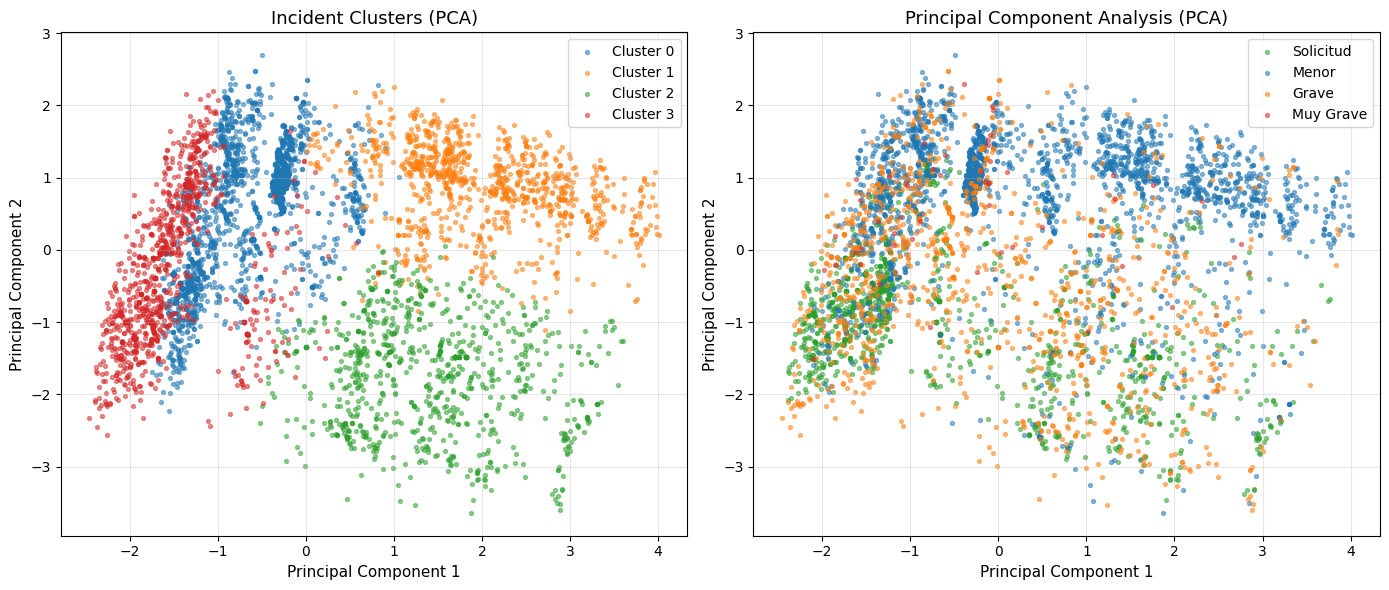

Variance Explained by PCA1: 25.7%
Variance Explained by PCA2: 16.6%
Total information displayed: 42.3%


In [30]:
pca = PCA(n_components=2, random_state=42)
componentes_pca = pca.fit_transform(datos_escalados)

df_pca = pd.DataFrame()
df_pca['PCA1'] = componentes_pca[:, 0]
df_pca['PCA2'] = componentes_pca[:, 1]
df_pca['CLUSTER'] = df_cluster['CLUSTER'].values
df_pca['IMPORTANCIA'] = df_cluster['IMPORTANCIA'].values

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(k_elegido):
    datos = df_pca[df_pca['CLUSTER'] == i]
    plt.scatter(datos['PCA1'], datos['PCA2'], c=colores[i],
                label=f'Cluster {i}', alpha=0.5, s=8)
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.title('Incident Clusters (PCA)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
importancia_colores = {'Solicitud': '#2ca02c', 'Menor': '#1f77b4',
                        'Grave': '#ff7f0e', 'Muy Grave': '#d62728'}
for imp, color in importancia_colores.items():
    datos = df_pca[df_pca['IMPORTANCIA'] == imp]
    plt.scatter(datos['PCA1'], datos['PCA2'], c=color,
                label=imp, alpha=0.5, s=8)
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.title('Principal Component Analysis (PCA)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Variance Explained by PCA1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance Explained by PCA2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total information displayed: {sum(pca.explained_variance_ratio_)*100:.1f}%")

View cluster centroids and variance plot


CLUSTER CENTERS (in PCA space)
Cluster 0: PCA1=-0.71, PCA2=0.49
Cluster 1: PCA1=2.01, PCA2=0.87
Cluster 2: PCA1=1.41, PCA2=-1.72
Cluster 3: PCA1=-1.54, PCA2=-0.34


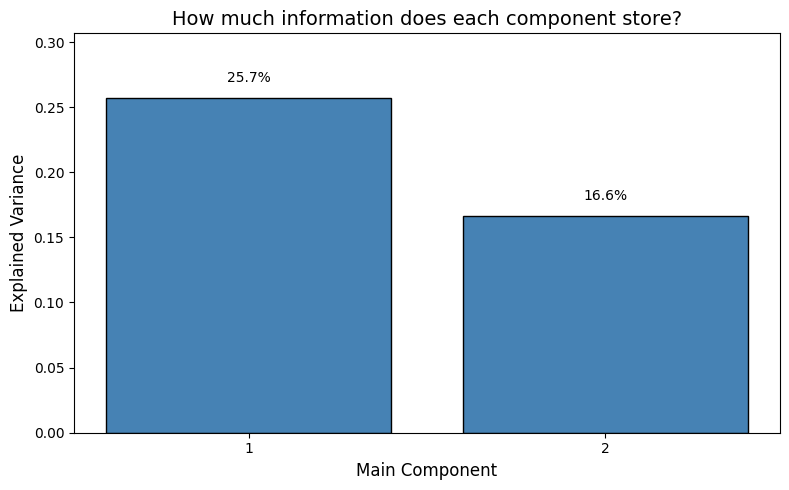

In [32]:
print("\n" + "="*50)
print("CLUSTER CENTERS (in PCA space)")
print("="*50)
centroides_pca = pca.transform(kmeans.cluster_centers_)
for i in range(k_elegido):
    print(f"Cluster {i}: PCA1={centroides_pca[i, 0]:.2f}, PCA2={centroides_pca[i, 1]:.2f}")

plt.figure(figsize=(8, 5))
bars = plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
                pca.explained_variance_ratio_,
                color='steelblue', edgecolor='black')
plt.xlabel('Main Component', fontsize=12)
plt.ylabel('Explained Variance', fontsize=12)
plt.title('How much information does each component store?', fontsize=14)
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))

for i, (bar, var) in enumerate(zip(bars, pca.explained_variance_ratio_)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{var*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(pca.explained_variance_ratio_) + 0.05)
plt.tight_layout()
plt.show()